## Task 1 - Implementation and Algorithm Trace

`A = [10, 7, 8, 9, 1, 5]`

Lomuto partition uses the last element of each current subarray as the pivot. Pivot positions below use Python's zero-based indices.

In [1]:
def partition(A, low, high):
    pivot = A[high]
    boundary = low - 1
    for j in range(low, high):
        if A[j] <= pivot:
            boundary += 1
            A[boundary], A[j] = A[j], A[boundary]
    pivot_index = boundary + 1
    A[pivot_index], A[high] = A[high], A[pivot_index]
    return pivot_index


def quicksort_last(A, low=0, high=None, trace=False, pivots=None):
    if high is None:
        high = len(A) - 1
    if low < high:
        selected = A[high]
        pivot_index = partition(A, low, high)
        if pivots is not None:
            pivots.append(selected)
        if trace:
            print(f"Selected pivot: {selected}; subarray indices: {low}..{high}")
            print(f"After partition: {A}")
            print(f"Final pivot position: {pivot_index} (zero-based)\n")
        quicksort_last(A, low, pivot_index - 1, trace, pivots)
        quicksort_last(A, pivot_index + 1, high, trace, pivots)
    return A


A = [10, 7, 8, 9, 1, 5]
print('Original array:')
print(A)
quicksort_last(A, trace=True)
print('Final sorted array:')
print(A)
assert A == [1, 5, 7, 8, 9, 10]

Original array:
[10, 7, 8, 9, 1, 5]
Selected pivot: 5; subarray indices: 0..5
After partition: [1, 5, 8, 9, 10, 7]
Final pivot position: 1 (zero-based)

Selected pivot: 7; subarray indices: 2..5
After partition: [1, 5, 7, 9, 10, 8]
Final pivot position: 2 (zero-based)

Selected pivot: 8; subarray indices: 3..5
After partition: [1, 5, 7, 8, 10, 9]
Final pivot position: 3 (zero-based)

Selected pivot: 9; subarray indices: 4..5
After partition: [1, 5, 7, 8, 9, 10]
Final pivot position: 4 (zero-based)

Final sorted array:
[1, 5, 7, 8, 9, 10]


### Recursive Execution

The tree records each processed subarray **before** partitioning. `L` and `R` are the two subarrays **after** partitioning; the pivot is already in its final position.

```text
[10, 7, 8, 9, 1, 5]  pivot 5  -> L=[1], R=[8, 9, 10, 7]
├── [1]                         base case
└── [8, 9, 10, 7]      pivot 7  -> L=[], R=[9, 10, 8]
    ├── []                      base case
    └── [9, 10, 8]     pivot 8  -> L=[], R=[10, 9]
        ├── []                  base case
        └── [10, 9]   pivot 9  -> L=[], R=[10]
            ├── []              base case
            └── [10]            base case
```

1. `PARTITION` places the pivot at its final sorted position and separates values at most the pivot from greater values.
2. Immediately after partitioning, every value to the pivot's left is `<= pivot`, and every value to its right is `> pivot` within the processed subarray.
3. The base case is a subarray containing zero or one element (`low >= high`).
4. Quick Sort partitions around a pivot and recursively sorts the resulting parts. Merge Sort first splits into fixed halves, recursively sorts them, then combines them with a merge step.

## Task 2 - Modified Quick Sort

`A = [12, 5, 8, 1, 19, 4, 15, 7]`

The second implementation selects index `(low + high) // 2`, swaps that value with the last value, and then uses the **same Lomuto `partition` function** as Task 1.

In [2]:
def partition_middle(A, low, high):
    middle = (low + high) // 2
    A[middle], A[high] = A[high], A[middle]
    return partition(A, low, high)


def quicksort_middle(A, low=0, high=None, pivots=None):
    if high is None:
        high = len(A) - 1
    if low < high:
        selected = A[(low + high) // 2]
        pivot_index = partition_middle(A, low, high)
        if pivots is not None:
            pivots.append(selected)
        quicksort_middle(A, low, pivot_index - 1, pivots)
        quicksort_middle(A, pivot_index + 1, high, pivots)
    return A


original = [12, 5, 8, 1, 19, 4, 15, 7]
last_data = original.copy()
middle_data = original.copy()
last_pivots = []
middle_pivots = []
print('Original array:', original)
print('Last-element pivot result:', quicksort_last(last_data, pivots=last_pivots))
print('Last-element pivot sequence:', last_pivots)
print('Middle-element pivot result:', quicksort_middle(middle_data, pivots=middle_pivots))
print('Middle-element pivot sequence:', middle_pivots)
assert last_data == middle_data == [1, 4, 5, 7, 8, 12, 15, 19]

Original array: [12, 5, 8, 1, 19, 4, 15, 7]
Last-element pivot result: [1, 4, 5, 7, 8, 12, 15, 19]
Last-element pivot sequence: [7, 4, 12, 19]
Middle-element pivot result: [1, 4, 5, 7, 8, 12, 15, 19]
Middle-element pivot sequence: [1, 19, 7, 5, 8, 15]


The selected pivot determines which values go into the left and right parts at each step. The middle **position** can give a more balanced split on already sorted, distinct values, while the last position gives a `0 : n-1` split there. The middle position is not necessarily the median value, so neither strategy guarantees balanced partitions for every input.

## Task 3 - Counting Comparisons and Swaps

Count one comparison for every evaluated `A[j] <= pivot` in Lomuto partition. Count an exchange only when it changes **two different indices**; self-swaps are excluded.

In [3]:
def quicksort_counted(values):
    A = values.copy()
    comparisons = 0
    swaps = 0

    def counted_partition(low, high):
        nonlocal comparisons, swaps
        pivot = A[high]
        boundary = low - 1
        for j in range(low, high):
            comparisons += 1
            if A[j] <= pivot:
                boundary += 1
                if boundary != j:
                    A[boundary], A[j] = A[j], A[boundary]
                    swaps += 1
        pivot_index = boundary + 1
        if pivot_index != high:
            A[pivot_index], A[high] = A[high], A[pivot_index]
            swaps += 1
        return pivot_index

    def sort(low, high):
        if low < high:
            pivot_index = counted_partition(low, high)
            sort(low, pivot_index - 1)
            sort(pivot_index + 1, high)

    sort(0, len(A) - 1)
    return A, comparisons, swaps


test_arrays = {
    'Sorted array': [1, 2, 3, 4, 5, 6, 7, 8],
    'Reverse-sorted array': [8, 7, 6, 5, 4, 3, 2, 1],
    'Random array': [7, 2, 8, 4, 1, 6, 5, 3],
}
print(f"{'Input':<23} {'Comparisons':>12} {'Swaps':>7}")
print('-' * 44)
for label, data in test_arrays.items():
    result, comparisons, swaps = quicksort_counted(data)
    assert result == sorted(data)
    print(f'{label:<23} {comparisons:>12} {swaps:>7}')

Input                    Comparisons   Swaps
--------------------------------------------
Sorted array                      28       0
Reverse-sorted array              28       4
Random array                      16       5


### Answers

1. The already sorted and reverse-sorted inputs tie for the **largest** number of comparisons: 28 each.
2. The random-order input has the **smallest** number: 16.
3. With already sorted distinct values, the last value is always the largest. Each partition leaves `n-1` elements on one side and none on the other, so the total comparisons are `7 + 6 + ... + 1 = 28` for eight elements.
4. Balanced partitions give a recursion tree of depth about `log₂ n`; highly unbalanced partitions give depth about `n`. A binary recursive implementation still creates a linear number of calls overall, but imbalance makes its **maximum call depth** and comparison count much larger.
5. Merge Sort splits into approximately equal halves regardless of input order, so its `Θ(n log n)` growth is stable. Heap Sort maintains `O(n log n)` across input orders. This last-pivot Quick Sort reaches `Θ(n²)` on both sorted and reverse-sorted distinct inputs.

## Task 4 - Experimental Analysis and Comparison

All times below are wall-clock seconds measured with `time.perf_counter()`. Each mean uses **five runs**. Array generation and copying happen before the timer; result checks happen after it. Fixed random seeds make input arrays reproducible. Exact times depend on the computer and Python environment.

Input size n    Average execution time (s)
--------------------------------------------
         100                      0.000062
         500                      0.000414
        1000                      0.000932
        5000                      0.005682
       10000                      0.012008
       50000                      0.070646


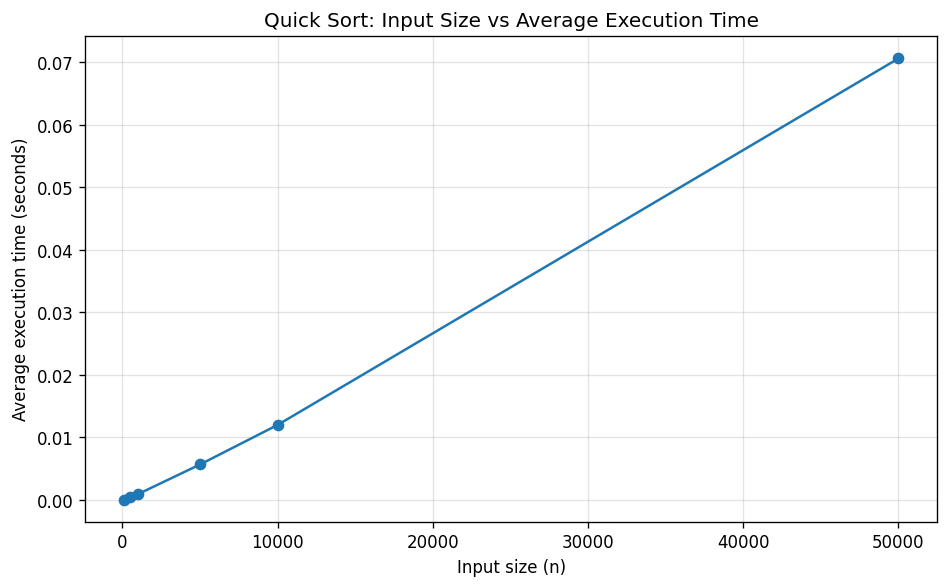

In [4]:
import random
import sys
import time
import matplotlib.pyplot as plt

sys.setrecursionlimit(max(sys.getrecursionlimit(), 12000))


def measure_sort(sort_function, values):
    data = values.copy()
    start = time.perf_counter()
    result = sort_function(data)
    elapsed = time.perf_counter() - start
    assert result == sorted(values)
    return elapsed


quick_sizes = [100, 500, 1000, 5000, 10000, 50000]
quick_times = []
for n in quick_sizes:
    runs = []
    for trial in range(5):
        rng = random.Random(20261006 + 10 * n + trial)
        values = rng.sample(range(10 * n), n)
        runs.append(measure_sort(quicksort_last, values))
    quick_times.append(sum(runs) / len(runs))

print(f"{'Input size n':>12}  {'Average execution time (s)':>28}")
print('-' * 44)
for n, elapsed in zip(quick_sizes, quick_times):
    print(f'{n:>12}  {elapsed:>28.6f}')

plt.figure(figsize=(8, 5))
plt.plot(quick_sizes, quick_times, marker='o', label='Quick Sort (last pivot)')
plt.xlabel('Input size (n)')
plt.ylabel('Average execution time (seconds)')
plt.title('Quick Sort: Input Size vs Average Execution Time')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Comparison of Four Sorting Algorithms

The implementations below use the algorithms from the previous labs. For each size and trial, all four algorithms receive copies of the **same random array**.

      n   Insertion (s)    Merge (s)     Heap (s)    Quick (s)
-----------------------------------------------------------------
    100        0.000189     0.000140     0.000123     0.000061
    500        0.004955     0.000736     0.000852     0.000426
   1000        0.021453     0.001633     0.001985     0.000922
   5000        0.536142     0.010087     0.012862     0.005785
  10000        2.140439     0.021771     0.027966     0.011988


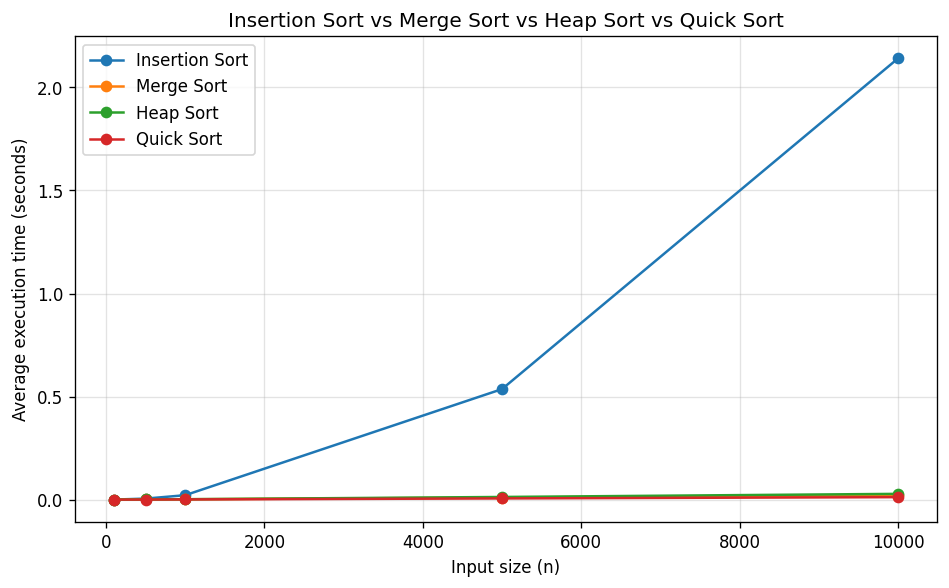

In [5]:
def insertion_sort(A):
    for j in range(1, len(A)):
        key = A[j]
        i = j - 1
        while i >= 0 and A[i] > key:
            A[i + 1] = A[i]
            i -= 1
        A[i + 1] = key
    return A


def merge_sort(A):
    if len(A) <= 1:
        return A
    middle = len(A) // 2
    left = merge_sort(A[:middle])
    right = merge_sort(A[middle:])
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    return merged + left[i:] + right[j:]


def max_heapify(A, heap_size, i):
    while True:
        left = 2 * i + 1
        right = 2 * i + 2
        largest = i
        if left < heap_size and A[left] > A[largest]:
            largest = left
        if right < heap_size and A[right] > A[largest]:
            largest = right
        if largest == i:
            return
        A[i], A[largest] = A[largest], A[i]
        i = largest


def heap_sort(A):
    for i in range(len(A) // 2 - 1, -1, -1):
        max_heapify(A, len(A), i)
    for end in range(len(A) - 1, 0, -1):
        A[0], A[end] = A[end], A[0]
        max_heapify(A, end, 0)
    return A


comparison_sizes = [100, 500, 1000, 5000, 10000]
algorithms = {
    'Insertion Sort': insertion_sort,
    'Merge Sort': merge_sort,
    'Heap Sort': heap_sort,
    'Quick Sort': quicksort_last,
}
comparison_times = {name: [] for name in algorithms}
for n in comparison_sizes:
    runs = {name: [] for name in algorithms}
    for trial in range(5):
        rng = random.Random(20261006 + 100 * n + trial)
        original = rng.sample(range(10 * n), n)
        for name, sort_function in algorithms.items():
            runs[name].append(measure_sort(sort_function, original))
    for name in algorithms:
        comparison_times[name].append(sum(runs[name]) / 5)

print(f"{'n':>7} {'Insertion (s)':>15} {'Merge (s)':>12} {'Heap (s)':>12} {'Quick (s)':>12}")
print('-' * 65)
for row in zip(comparison_sizes, *comparison_times.values()):
    print(f'{row[0]:>7} {row[1]:>15.6f} {row[2]:>12.6f} {row[3]:>12.6f} {row[4]:>12.6f}')

plt.figure(figsize=(8, 5))
for name, times in comparison_times.items():
    plt.plot(comparison_sizes, times, marker='o', label=name)
plt.xlabel('Input size (n)')
plt.ylabel('Average execution time (seconds)')
plt.title('Insertion Sort vs Merge Sort vs Heap Sort vs Quick Sort')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Effect of Pivot Selection

Both Task 2 versions use Lomuto partition. Each strategy runs five times on random, sorted, and reverse-sorted arrays of each required size. The array supplied to both strategies is identical within a trial.

In [6]:
pivot_sizes = [100, 1000, 5000]
pivot_functions = {
    'Last element': quicksort_last,
    'Middle element': quicksort_middle,
}
pivot_times = {}
for order in ['Random', 'Sorted', 'Reverse-sorted']:
    for n in pivot_sizes:
        samples = {name: [] for name in pivot_functions}
        for trial in range(5):
            if order == 'Random':
                rng = random.Random(20261006 + 1000 * n + trial)
                original = rng.sample(range(10 * n), n)
            elif order == 'Sorted':
                original = list(range(n))
            else:
                original = list(range(n - 1, -1, -1))
            for name, sort_function in pivot_functions.items():
                samples[name].append(measure_sort(sort_function, original))
        pivot_times[(order, n)] = {name: sum(v) / 5 for name, v in samples.items()}

print(f"{'Input order':<17} {'n':>6} {'Last pivot (s)':>16} {'Middle pivot (s)':>18}")
print('-' * 62)
for (order, n), times in pivot_times.items():
    print(f"{order:<17} {n:>6} {times['Last element']:>16.6f} {times['Middle element']:>18.6f}")

Input order            n   Last pivot (s)   Middle pivot (s)
--------------------------------------------------------------
Random               100         0.000069           0.000076
Random              1000         0.000963           0.001046
Random              5000         0.005510           0.006150
Sorted               100         0.000419           0.000060
Sorted              1000         0.040947           0.000725
Sorted              5000         1.068055           0.004584
Reverse-sorted       100         0.000289           0.000062
Reverse-sorted      1000         0.028338           0.000855
Reverse-sorted      5000         0.705481           0.005005


To check partition balance directly, the next cell counts the size of both sides at each partition on representative arrays of size 1000. The **mean smaller-side fraction** is `min(left, right) / (left + right)` averaged over partitions with at least two remaining values. It is near `0` for repeated empty-side splits and approaches `0.5` for balanced splits.

In [7]:
def mean_smaller_side_fraction(values, use_middle):
    A = values.copy()
    fractions = []
    stack = [(0, len(A) - 1)]
    while stack:
        low, high = stack.pop()
        if low >= high:
            continue
        if use_middle:
            pivot_index = partition_middle(A, low, high)
        else:
            pivot_index = partition(A, low, high)
        left_size = pivot_index - low
        right_size = high - pivot_index
        if left_size + right_size >= 2:
            fractions.append(min(left_size, right_size) / (left_size + right_size))
        stack.extend([(low, pivot_index - 1), (pivot_index + 1, high)])
    assert A == sorted(values)
    return sum(fractions) / len(fractions)


balance_inputs = {
    'Random': random.Random(20261006).sample(range(10000), 1000),
    'Sorted': list(range(1000)),
    'Reverse-sorted': list(range(999, -1, -1)),
}
print(f"{'Input order':<17} {'Last pivot':>12} {'Middle pivot':>14}")
print('-' * 46)
for label, values in balance_inputs.items():
    last = mean_smaller_side_fraction(values, False)
    middle = mean_smaller_side_fraction(values, True)
    print(f'{label:<17} {last:>12.3f} {middle:>14.3f}')

Input order         Last pivot   Middle pivot
----------------------------------------------
Random                   0.201          0.203
Sorted                   0.000          0.492
Reverse-sorted           0.000          0.313


### Answers

1. Quick Sort's measured time increases with `n`. On these distinct random inputs, the growth is consistent with its expected `Θ(n log n)` work.
2. For larger random arrays, Insertion Sort grows much faster. Merge Sort, Heap Sort, and Quick Sort scale more similarly. Exact ordering among the three `Θ(n log n)` algorithms depends on implementation and machine; the table above gives the measured values.
3. Pivot selection changes the partition sizes. On sorted and reverse-sorted arrays, the last-element pivot repeatedly creates an empty side, so it is much slower at large `n` than the middle-element pivot. Their times on random arrays are closer.
4. The middle-element strategy gives more balanced partitions on the sorted and reverse-sorted inputs, as the balance table shows. On random input, neither position is guaranteed to be the median value.
5. Yes. The approximately `n log n` pattern on random input and strong slowdown for last-pivot sorted/reverse-sorted input match the average and quadratic worst-case analyses. Short-run timing noise and Python overhead can affect exact ratios.

## Theoretical Analysis

1. Quick Sort has best-case `Θ(n log n)`, average-case `Θ(n log n)` under a random input/pivot model, and worst-case `Θ(n²)` running time.
2. A pivot that repeatedly makes a `0 : n-1` split causes `n-1`, then `n-2`, and so on comparisons, summing to `Θ(n²)`.
3. Approximately equal parts produce a recursion depth of `Θ(log n)` and `Θ(n)` partition work per level, giving `Θ(n log n)` total work.
4. If the pivot is always the smallest or largest value, one side is empty at every level and recursion depth grows to `Θ(n)`.

| Algorithm | Best Case | Average Case | Worst Case |
|---|---:|---:|---:|
| Insertion Sort | `Θ(n)` | `Θ(n²)` | `Θ(n²)` |
| Merge Sort | `Θ(n log n)` | `Θ(n log n)` | `Θ(n log n)` |
| Heap Sort | `Θ(n log n)` | `Θ(n log n)` | `Θ(n log n)` |
| Quick Sort | `Θ(n log n)` | `Θ(n log n)` | `Θ(n²)` |

For balanced partitions, `T(n) = 2T(n/2) + Θ(n)`: the two recursive terms sort the two halves, and `Θ(n)` is the partition scan. The solution is `Θ(n log n)`.

For highly unbalanced partitions, `T(n) = T(n-1) + Θ(n)`: one recursive side has `n-1` elements and the other is empty. Summing the partition scans gives `Θ(n²)`.

## Conclusion

Quick Sort places each pivot in its final position with Lomuto partition and recursively sorts the remaining parts. The two implementations return the same sorted result, but pivot position changes the recursion tree and measured time. A middle-position pivot improves balance for the sorted and reverse-sorted arrays tested here; it is not a guaranteed median. The experiments show Quick Sort's good scaling on random data and its quadratic vulnerability when a last-element pivot repeatedly gives an extreme split.